# Simple Image Segmentation — Complete Solutions
### All Tasks + Training Questions + Full Evaluation

## Setup — Install & Import

In [2]:
# Run this in Google Colab
!pip install -q kagglehub

In [3]:
import os
import re
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import kagglehub

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 3: Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


## Step 4: Download Dataset from Kaggle

In [15]:
DOWNLOAD_DIR = Path(
    kagglehub.dataset_download("nizier193/leaf-segmentation-dataset-mk7")
)
print("Downloaded to:", DOWNLOAD_DIR)

# Fix: Changed DRIVE_PROJECT_DIR to point to a directory instead of a file
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/leaf_segmentation_project")
DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = DRIVE_PROJECT_DIR / "dataset"

if not DATASET_DIR.exists():
    shutil.copytree(DOWNLOAD_DIR, DATASET_DIR)
    print("Copied dataset to Drive:", DATASET_DIR)
else:
    print("Dataset already exists in Drive:", DATASET_DIR)

Using Colab cache for faster access to the 'leaf-segmentation-dataset-mk7' dataset.
Downloaded to: /kaggle/input/leaf-segmentation-dataset-mk7
Dataset already exists in Drive: /content/drive/MyDrive/leaf_segmentation_project/dataset


## Step 5-7: Inspect and Find Folders

In [16]:
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(str(DATASET_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:3]:
        print(" " * 2 * (level + 1) + f)
    if level >= 2:
        continue

dataset/
  aug/
    images/
      image-332-0.jpg
      image-79-0.jpg
      image-70-0.jpg
    masks/
      mask-7-1.jpg
      mask-89-0.jpg
      mask-207-1.jpg


In [17]:
image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

all_dirs = [p for p in DATASET_DIR.rglob("*") if p.is_dir()]

def count_images(folder):
    return len([p for p in folder.glob("*") if p.suffix.lower() in image_exts])

image_candidates = []
mask_candidates  = []

for d in all_dirs:
    name = d.name.lower()
    n_files = count_images(d)
    if n_files == 0:
        continue
    if any(k in name for k in ["image", "images", "img", "rgb"]):
        image_candidates.append((d, n_files))
    if any(k in name for k in ["mask", "masks", "label", "labels", "annotation", "annotations"]):
        mask_candidates.append((d, n_files))

print("Image candidates:")
for d, n in image_candidates[:10]:
    print("-", d, "|", n)

print("\nMask candidates:")
for d, n in mask_candidates[:10]:
    print("-", d, "|", n)

IMAGE_DIR = sorted(image_candidates, key=lambda x: x[1], reverse=True)[0][0]
MASK_DIR  = sorted(mask_candidates,  key=lambda x: x[1], reverse=True)[0][0]

print("\nIMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)

Image candidates:
- /content/drive/MyDrive/leaf_segmentation_project/dataset/aug/images | 552

Mask candidates:
- /content/drive/MyDrive/leaf_segmentation_project/dataset/aug/masks | 552

IMAGE_DIR: /content/drive/MyDrive/leaf_segmentation_project/dataset/aug/images
MASK_DIR : /content/drive/MyDrive/leaf_segmentation_project/dataset/aug/masks


## Step 8: Helper Functions

In [18]:
def read_image(path, size=(256, 256)):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def read_mask(path, size=(256, 256)):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def show_many(images, titles, cols=3, size=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=size)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.35):
    out = image.copy()
    color_layer = np.zeros_like(image)
    color_layer[:, :] = color
    mask_bool = mask > 0
    out[mask_bool] = cv2.addWeighted(
        image[mask_bool], 1 - alpha,
        color_layer[mask_bool], alpha, 0
    )
    return out

def largest_component(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + np.argmax(areas)
    out = np.zeros_like(binary)
    out[labels == largest_idx] = 255
    return out

def segment_simple(image, kernel_size=(5, 5), use_inv=True):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, kernel_size, 0)
    thresh_type = cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU if use_inv else cv2.THRESH_BINARY + cv2.THRESH_OTSU
    _, mask = cv2.threshold(blur, 0, 255, thresh_type)
    kernel = np.ones(kernel_size, np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = largest_component(mask)
    return gray, blur, mask

def to_binary(mask):
    return (mask > 0).astype(np.uint8)

def segmentation_metrics(y_true, y_pred):
    y_true = to_binary(y_true).flatten()
    y_pred = to_binary(y_pred).flatten()
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    accuracy  = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    dice      = 2 * tp / (2 * tp + fp + fn + 1e-8)
    return {"accuracy": accuracy, "precision": precision,
            "recall": recall, "f1_score": f1, "iou": iou, "dice": dice}

print("Helper and Segmentation functions ready.")

Helper and Segmentation functions ready.


## Step 9: Build Image-Mask Pairs

In [19]:
def list_image_files(folder):
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in image_exts])

def extract_id(name):
    name = Path(name).stem.lower()
    m = re.search(r"(\d+-\d+)$", name)
    if m:
        return m.group(1)
    nums = re.findall(r"\d+", name)
    if len(nums) >= 2:
        return f"{nums[-2]}-{nums[-1]}"
    elif len(nums) == 1:
        return nums[0]
    return name

def build_pairs(image_dir, mask_dir):
    image_files = list_image_files(image_dir)
    mask_files  = list_image_files(mask_dir)
    mask_map = {extract_id(m.name): m for m in mask_files}
    pairs = []
    for img_path in image_files:
        key = extract_id(img_path.name)
        if key in mask_map:
            pairs.append((img_path, mask_map[key]))
    return pairs

pairs = build_pairs(IMAGE_DIR, MASK_DIR)

print("Images found:", len(list_image_files(IMAGE_DIR)))
print("Masks found :", len(list_image_files(MASK_DIR)))
print("Pairs found :", len(pairs))

Images found: 552
Masks found : 552
Pairs found : 552


## Step 10: Preview One Image + Mask

--- 'image5.jpg' uchun ko'rib chiqish ---


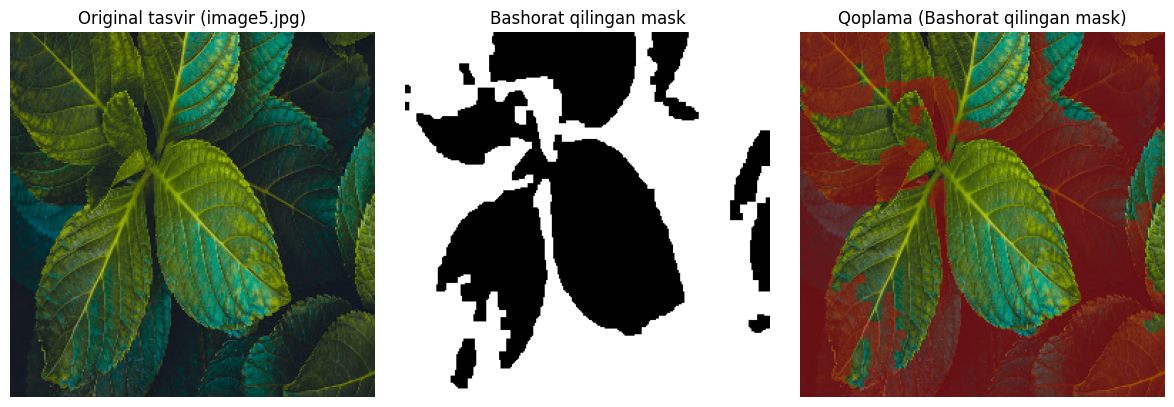

Qayta ishlangan tasvir: image5.jpg
Izoh: 'image5.jpg' uchun 'Haqiqiy mask' mavjud emas, shuning uchun 'Bashorat qilingan mask' ko'rsatilgan.

--- Loyihaning birinchi tasviri uchun asl ko'rib chiqish (keyingi qadamlar uchun) ---


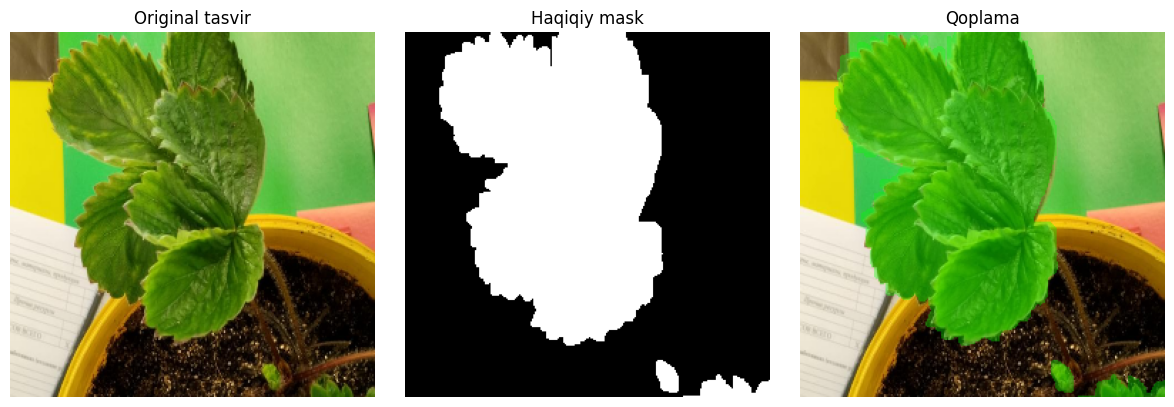

Tasvir: image-0-0.jpg
Mask : mask-0-0.jpg


In [20]:
print("--- 'image5.jpg' uchun ko'rib chiqish ---")
custom_img_path = Path("/content/drive/MyDrive/image5.jpg")

# Maxsus tasvirni o'qish
if not custom_img_path.exists():
    raise FileNotFoundError(f"Fayl topilmadi: {custom_img_path}. Iltimos, fayl yo'li to'g'ri ekanligiga ishonch hosil qiling.")

custom_img = read_image(custom_img_path)

# Maxsus tasvirni segmentatsiya qilish va bashorat qilingan maskni olish
# segment_simple funksiyasi umumiy tasvirlar uchun yetarlicha mustahkam deb hisoblanadi.
_, _, custom_pred_mask = segment_simple(custom_img)

# Bashorat qilingan mask bilan qoplama yaratish
custom_over = overlay_mask(custom_img, custom_pred_mask, color=(255, 0, 0)) # Bashorat qilingan mask uchun qizil rang

show_many(
    [custom_img, custom_pred_mask, custom_over],
    ["Original tasvir (image5.jpg)", "Bashorat qilingan mask", "Qoplama (Bashorat qilingan mask)"],
    cols=3, size=(12, 4)
)

print(f"Qayta ishlangan tasvir: {custom_img_path.name}")
print("Izoh: 'image5.jpg' uchun 'Haqiqiy mask' mavjud emas, shuning uchun 'Bashorat qilingan mask' ko'rsatilgan.")

# --- Keyingi hujayralar uchun asl 'Step 10' mantiqini tiklash ---
print("\n--- Loyihaning birinchi tasviri uchun asl ko'rib chiqish (keyingi qadamlar uchun) ---")
if len(pairs) == 0:
    raise ValueError("No image-mask pairs found. Check IMAGE_DIR and MASK_DIR.")

img_path, mask_path = pairs[0]

img  = read_image(img_path)
gt   = read_mask(mask_path)
over = overlay_mask(img, gt, color=(0, 255, 0))

show_many(
    [img, gt, over],
    ["Original tasvir", "Haqiqiy mask", "Qoplama"],
    cols=3, size=(12, 4)
)

print("Tasvir:", img_path.name)
print("Mask :", mask_path.name)

## Segmentation Functions + Metrics

In [ ]:
# Segmentation functions have been moved to the earlier helper functions cell (p-z6gIOw8D5V).
print("Segmentation functions were previously defined here. They have been moved.")

## Step 11-13: Segment One Image + Metrics

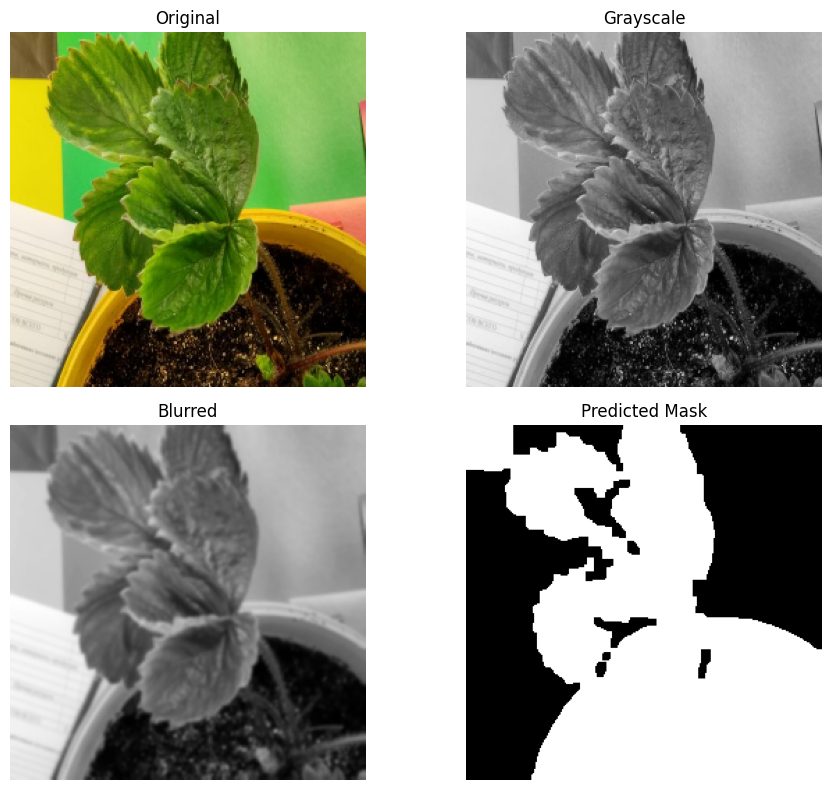

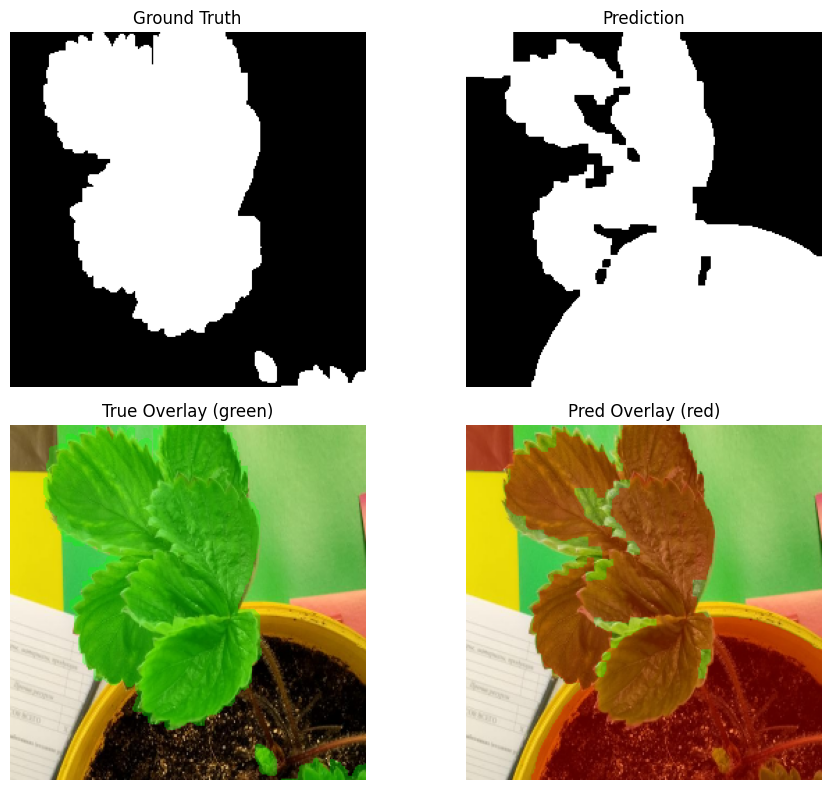


Metrics for one image:
  accuracy    : 0.7066
  precision   : 0.5993
  recall      : 0.8383
  f1_score    : 0.6990
  iou         : 0.5372
  dice        : 0.6990


In [21]:
gray, blur, pred = segment_simple(img)

show_many(
    [img, gray, blur, pred],
    ["Original", "Grayscale", "Blurred", "Predicted Mask"],
    cols=2, size=(10, 8)
)

show_many(
    [gt, pred,
     overlay_mask(img, gt,   color=(0, 255, 0)),
     overlay_mask(img, pred, color=(255, 0, 0))],
    ["Ground Truth", "Prediction", "True Overlay (green)", "Pred Overlay (red)"],
    cols=2, size=(10, 8)
)

metrics = segmentation_metrics(gt, pred)
print("\nMetrics for one image:")
for k, v in metrics.items():
    print(f"  {k:12s}: {v:.4f}")

## Step 14-15: Evaluate 50 Images + Average

In [22]:
results = []

for img_path, mask_path in pairs[:50]:
    img_i = read_image(img_path)
    gt_i  = read_mask(mask_path)
    _, _, pred_i = segment_simple(img_i)
    m = segmentation_metrics(gt_i, pred_i)
    row = {"image": img_path.name}
    row.update(m)
    results.append(row)

df = pd.DataFrame(results)
print("First 5 rows:")
display(df.head())

print("\nAverage metrics across 50 images:")
summary = df.mean(numeric_only=True)
for k, v in summary.items():
    print(f"  {k:12s}: {v:.4f}")

First 5 rows:


,image,accuracy,precision,recall,f1_score,iou,dice
0,image-0-0.jpg,0.706558,0.599345,0.838277,0.698956,0.537227,0.698956
1,image-0-1.jpg,0.605835,0.732726,0.718291,0.725437,0.569165,0.725437
2,image-1-0.jpg,0.688293,0.470018,0.950381,0.628973,0.458761,0.628973
3,image-1-1.jpg,0.668976,0.418026,0.836486,0.557464,0.386447,0.557464
4,image-10-0.jpg,0.705688,0.713589,0.640945,0.675319,0.509797,0.675319



Average metrics across 50 images:
  accuracy    : 0.6784
  precision   : 0.6945
  recall      : 0.6595
  f1_score    : 0.6228
  iou         : 0.4929
  dice        : 0.6228


## Step 16: Save Results

In [24]:
RESULTS_DIR = DRIVE_PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(RESULTS_DIR / "simple_segmentation_results.csv", index=False)
print("Saved to:", RESULTS_DIR / "simple_segmentation_results.csv")

Saved to: /content/drive/MyDrive/leaf_segmentation_project/results/simple_segmentation_results.csv


---
# Training Questions — Answers

In [25]:
print("Q1: Why do we convert the image to grayscale?")
print("    Color images have 3 channels (R, G, B). Thresholding works on")
print("    a single intensity value per pixel. Converting to grayscale gives")
print("    us one channel representing overall brightness, which is simpler")
print("    to threshold and sufficient for shape-based segmentation.")
print()
print("Q2: Why do we apply Gaussian blur?")
print("    Raw images have pixel-level noise. If we threshold a noisy image,")
print("    the noise creates many tiny false regions in the mask.")
print("    Gaussian blur averages neighboring pixels, smoothing out noise,")
print("    so thresholding produces a cleaner, more connected region.")
print()
print("Q3: What does Otsu thresholding do?")
print("    Otsu automatically finds the BEST threshold value by analyzing")
print("    the image histogram. It finds the value that minimizes the")
print("    variance WITHIN each class (foreground and background).")
print("    This means we don't have to manually pick a threshold — Otsu")
print("    adapts to each image's brightness distribution.")
print()
print("Q4: Why do we use opening and closing?")
print("    Opening (erosion then dilation): removes small noise pixels and")
print("    disconnected tiny blobs outside the main object.")
print("    Closing (dilation then erosion): fills small holes and gaps")
print("    INSIDE the main object, making the mask more solid.")
print("    Together they clean the binary mask significantly.")
print()
print("Q5: Why do we keep the largest component?")
print("    After thresholding and morphology, there may still be multiple")
print("    disconnected white regions. In leaf segmentation, we expect one")
print("    main object (the leaf). Keeping only the largest connected region")
print("    removes small false positives from the background.")
print()
print("Q6: Which metric is more useful: IoU or Dice?")
print("    Both measure overlap, but they emphasize it differently:")
print("    - IoU (Intersection over Union) = TP / (TP + FP + FN)")
print("      It penalizes mistakes more heavily. Preferred in detection tasks.")
print("    - Dice = 2*TP / (2*TP + FP + FN)")
print("      It gives more weight to overlap and is more common in medical")
print("      image segmentation. Dice is generally higher than IoU numerically.")
print("    For segmentation benchmarks, IoU is the more strict and widely")
print("    used standard. Dice is preferred in medical contexts.")
print()
print("Q7: In which cases might this simple method fail?")
print("    1. Background and leaf have similar brightness (low contrast).")
print("    2. Image has uneven lighting (one side dark, one bright).")
print("    3. Multiple overlapping leaves — only one will be kept.")
print("    4. Leaf has holes or complex internal structure.")
print("    5. Background has texture similar to the leaf.")
print("    6. Very small or very large objects relative to image size.")

Q1: Why do we convert the image to grayscale?
    Color images have 3 channels (R, G, B). Thresholding works on
    a single intensity value per pixel. Converting to grayscale gives
    us one channel representing overall brightness, which is simpler
    to threshold and sufficient for shape-based segmentation.

Q2: Why do we apply Gaussian blur?
    Raw images have pixel-level noise. If we threshold a noisy image,
    the noise creates many tiny false regions in the mask.
    Gaussian blur averages neighboring pixels, smoothing out noise,
    so thresholding produces a cleaner, more connected region.

Q3: What does Otsu thresholding do?
    Otsu automatically finds the BEST threshold value by analyzing
    the image histogram. It finds the value that minimizes the
    variance WITHIN each class (foreground and background).
    This means we don't have to manually pick a threshold — Otsu
    adapts to each image's brightness distribution.

Q4: Why do we use opening and closing?
    Ope

---
# Task 1 — Kernel Size (5,5) vs (3,3)

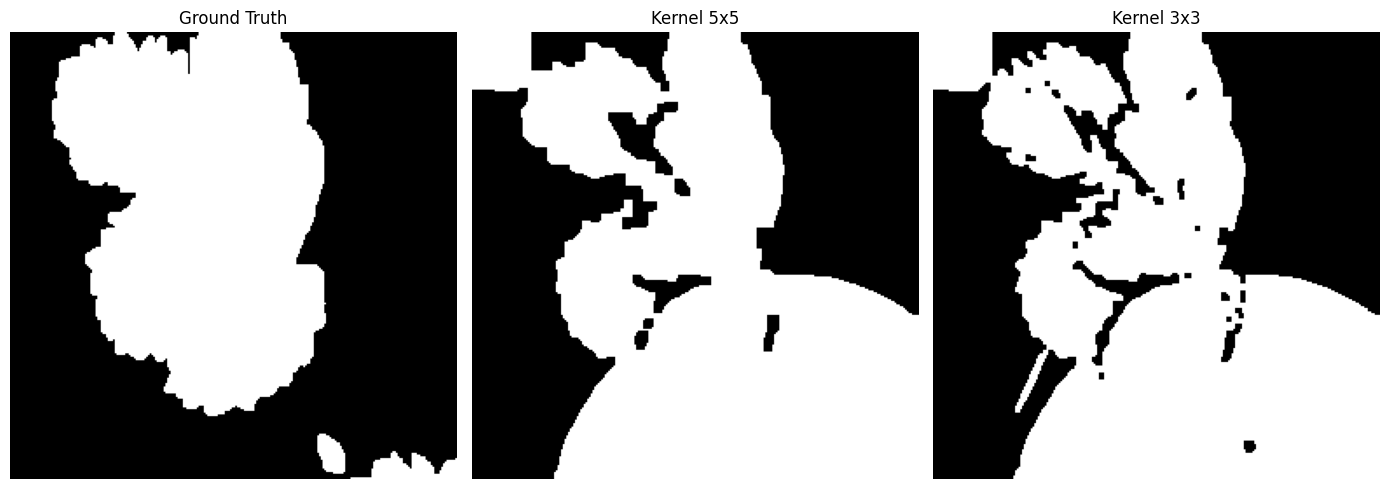

Metric         Kernel 5x5   Kernel 3x3
--------------------------------------
accuracy           0.7066       0.6991
precision          0.5993       0.5931
recall             0.8383       0.8264
f1_score           0.6990       0.6906
iou                0.5372       0.5274
dice               0.6990       0.6906

Task 1 Conclusion:
- Kernel 5x5: More aggressive morphological operations.
  Fills larger holes and removes more noise, but may erode fine edges.
- Kernel 3x3: Finer, preserves more boundary detail, but leaves more noise.
  Better when the object has thin structures.


In [26]:
# Task 1: Compare kernel (5,5) vs (3,3)

img_t1 = read_image(pairs[0][0])
gt_t1  = read_mask(pairs[0][1])

_, _, pred_5x5 = segment_simple(img_t1)  # default kernel (5,5)

# kernel (3,3)
gray3 = cv2.cvtColor(img_t1, cv2.COLOR_RGB2GRAY)
blur3 = cv2.GaussianBlur(gray3, (3, 3), 0)
_, mask3 = cv2.threshold(blur3, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel3 = np.ones((3, 3), np.uint8)
mask3 = cv2.morphologyEx(mask3, cv2.MORPH_OPEN, kernel3)
mask3 = cv2.morphologyEx(mask3, cv2.MORPH_CLOSE, kernel3)
pred_3x3 = largest_component(mask3)

show_many(
    [gt_t1, pred_5x5, pred_3x3],
    ["Ground Truth", "Kernel 5x5", "Kernel 3x3"],
    cols=3, size=(14, 5)
)

m5 = segmentation_metrics(gt_t1, pred_5x5)
m3 = segmentation_metrics(gt_t1, pred_3x3)

print(f"{'Metric':<12} {'Kernel 5x5':>12} {'Kernel 3x3':>12}")
print("-" * 38)
for k in m5:
    print(f"{k:<12} {m5[k]:>12.4f} {m3[k]:>12.4f}")

print()
print("Task 1 Conclusion:")
print("- Kernel 5x5: More aggressive morphological operations.")
print("  Fills larger holes and removes more noise, but may erode fine edges.")
print("- Kernel 3x3: Finer, preserves more boundary detail, but leaves more noise.")
print("  Better when the object has thin structures.")

---
# Task 2 — THRESH_BINARY vs THRESH_BINARY_INV

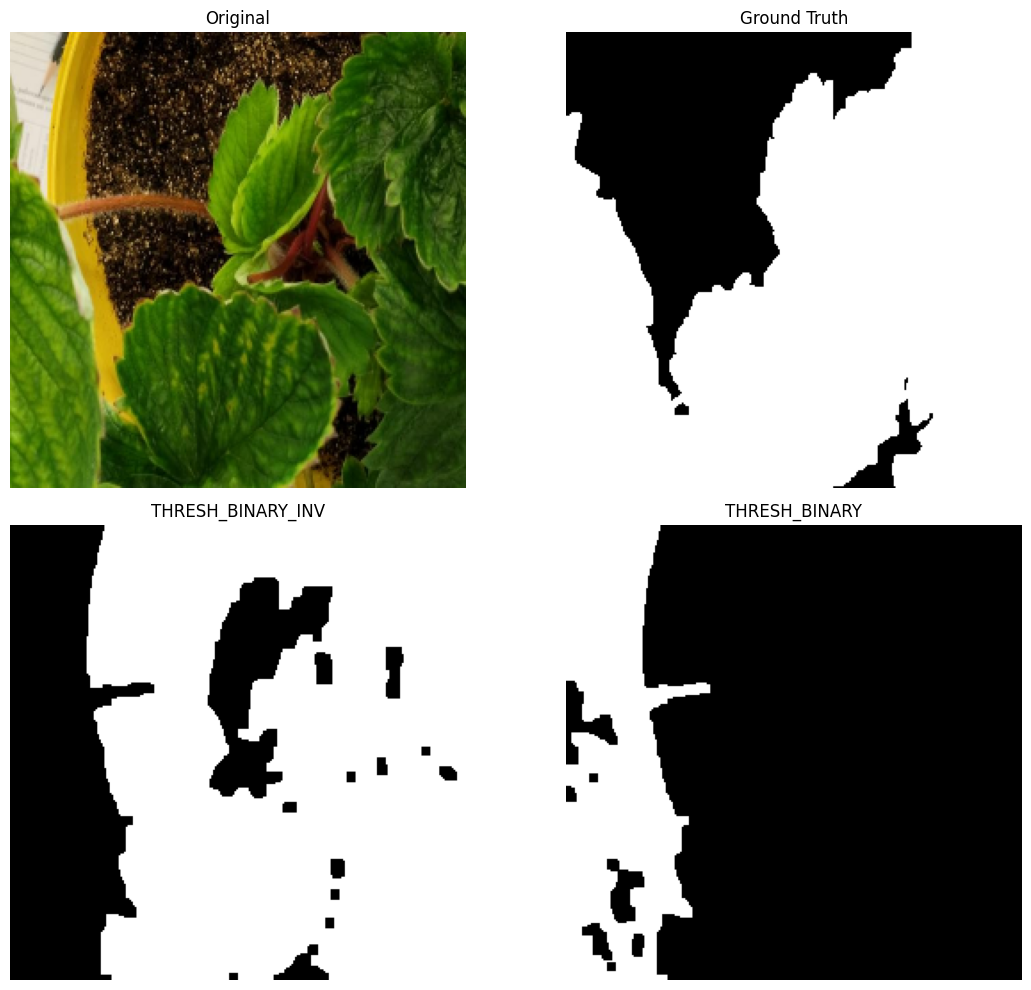

Metric         BINARY_INV       BINARY
--------------------------------------
accuracy           0.6058       0.3014
precision          0.7327       0.5694
recall             0.7183       0.1491
f1_score           0.7254       0.2364
iou                0.5692       0.1340
dice               0.7254       0.2364

Task 2 Explanation:
THRESH_BINARY_INV: pixels BELOW threshold become white (255).
  Use when the OBJECT is darker than the background.
  Example: dark leaf on white/bright background.

THRESH_BINARY: pixels ABOVE threshold become white (255).
  Use when the OBJECT is brighter than the background.
  Example: bright leaf on dark background.

Which to use depends on the image. Always check visually!


In [27]:
# Task 2: THRESH_BINARY vs THRESH_BINARY_INV

img_t2 = read_image(pairs[1][0])
gt_t2  = read_mask(pairs[1][1])

_, _, pred_inv    = segment_simple(img_t2, use_inv=True)   # BINARY_INV
_, _, pred_normal = segment_simple(img_t2, use_inv=False)  # BINARY

show_many(
    [img_t2, gt_t2, pred_inv, pred_normal],
    ["Original", "Ground Truth",
     "THRESH_BINARY_INV", "THRESH_BINARY"],
    cols=2, size=(12, 10)
)

m_inv = segmentation_metrics(gt_t2, pred_inv)
m_nor = segmentation_metrics(gt_t2, pred_normal)

print(f"{'Metric':<12} {'BINARY_INV':>12} {'BINARY':>12}")
print("-" * 38)
for k in m_inv:
    print(f"{k:<12} {m_inv[k]:>12.4f} {m_nor[k]:>12.4f}")

print()
print("Task 2 Explanation:")
print("THRESH_BINARY_INV: pixels BELOW threshold become white (255).")
print("  Use when the OBJECT is darker than the background.")
print("  Example: dark leaf on white/bright background.")
print()
print("THRESH_BINARY: pixels ABOVE threshold become white (255).")
print("  Use when the OBJECT is brighter than the background.")
print("  Example: bright leaf on dark background.")
print()
print("Which to use depends on the image. Always check visually!")

---
# Task 3 — Test on 10 More Images + Compare Metrics

,index,image,iou,dice,accuracy
0,1,image-0-1.jpg,0.5692,0.7254,0.6058
1,2,image-1-0.jpg,0.4588,0.6290,0.6883
2,3,image-1-1.jpg,0.3864,0.5575,0.6690
3,4,image-10-0.jpg,0.5098,0.6753,0.7057
4,5,image-100-0.jpg,0.2953,0.4560,0.6004
5,6,image-100-1.jpg,0.2340,0.3793,0.4898
6,7,image-101-0.jpg,0.5562,0.7148,0.6081
7,8,image-101-1.jpg,0.8352,0.9102,0.8987
8,9,image-102-0.jpg,0.2507,0.4009,0.6462
9,10,image-102-1.jpg,0.6504,0.7882,0.7940


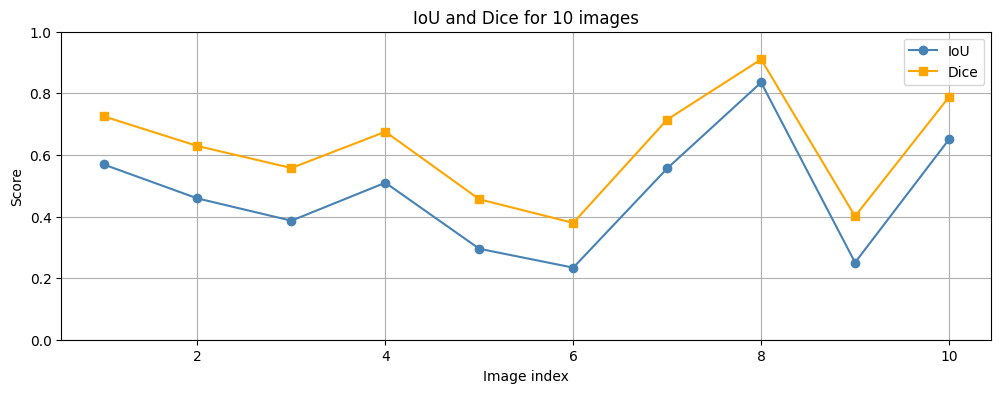


Average over 10 images:
  IoU : 0.4746
  Dice: 0.6236
  Acc : 0.6706


In [28]:
# Task 3: Test on 10 more images (indices 1-10) and compare metrics

task3_results = []

for i, (img_path, mask_path) in enumerate(pairs[1:11]):
    img_i = read_image(img_path)
    gt_i  = read_mask(mask_path)
    _, _, pred_i = segment_simple(img_i)
    m = segmentation_metrics(gt_i, pred_i)
    task3_results.append({
        "index": i + 1,
        "image": img_path.name,
        **m
    })

df3 = pd.DataFrame(task3_results)
display(df3[["index", "image", "iou", "dice", "accuracy"]].round(4))

# Plot IoU and Dice per image
plt.figure(figsize=(12, 4))
x = df3["index"]
plt.plot(x, df3["iou"],  marker="o", label="IoU",  color="steelblue")
plt.plot(x, df3["dice"], marker="s", label="Dice", color="orange")
plt.xlabel("Image index")
plt.ylabel("Score")
plt.title("IoU and Dice for 10 images")
plt.legend()
plt.ylim(0, 1)
plt.grid(True)
plt.show()

print(f"\nAverage over 10 images:")
print(f"  IoU : {df3['iou'].mean():.4f}")
print(f"  Dice: {df3['dice'].mean():.4f}")
print(f"  Acc : {df3['accuracy'].mean():.4f}")

---
# Task 4 — 3 Success Cases + 3 Failure Cases

=== 3 SUCCESS CASES (highest IoU) ===


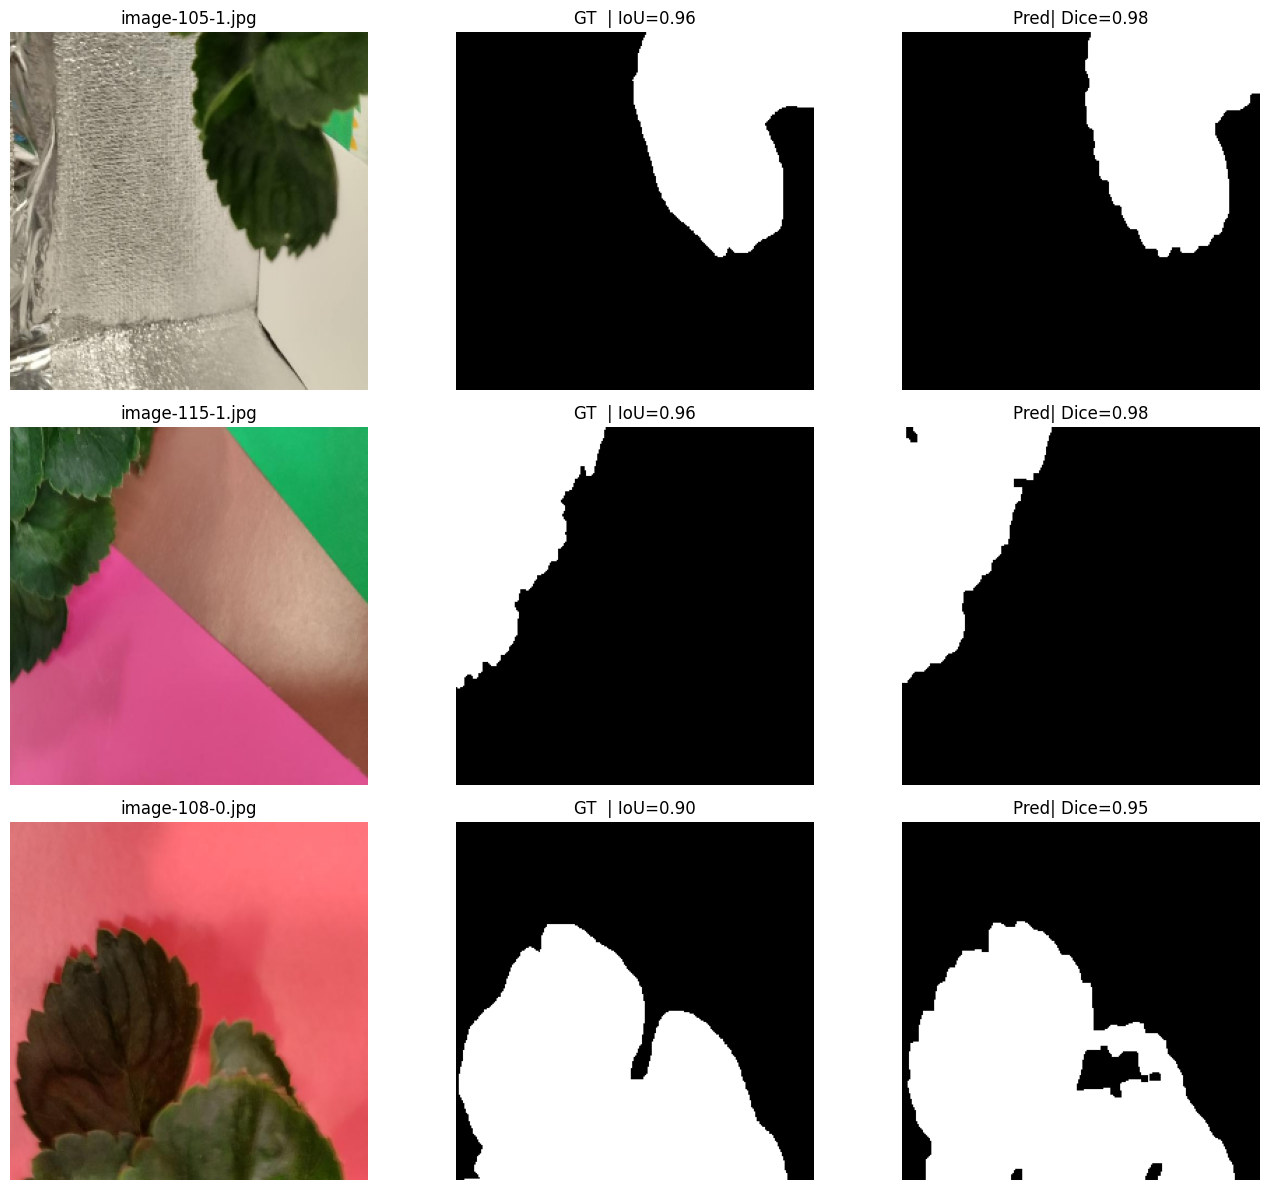

=== 3 FAILURE CASES (lowest IoU) ===


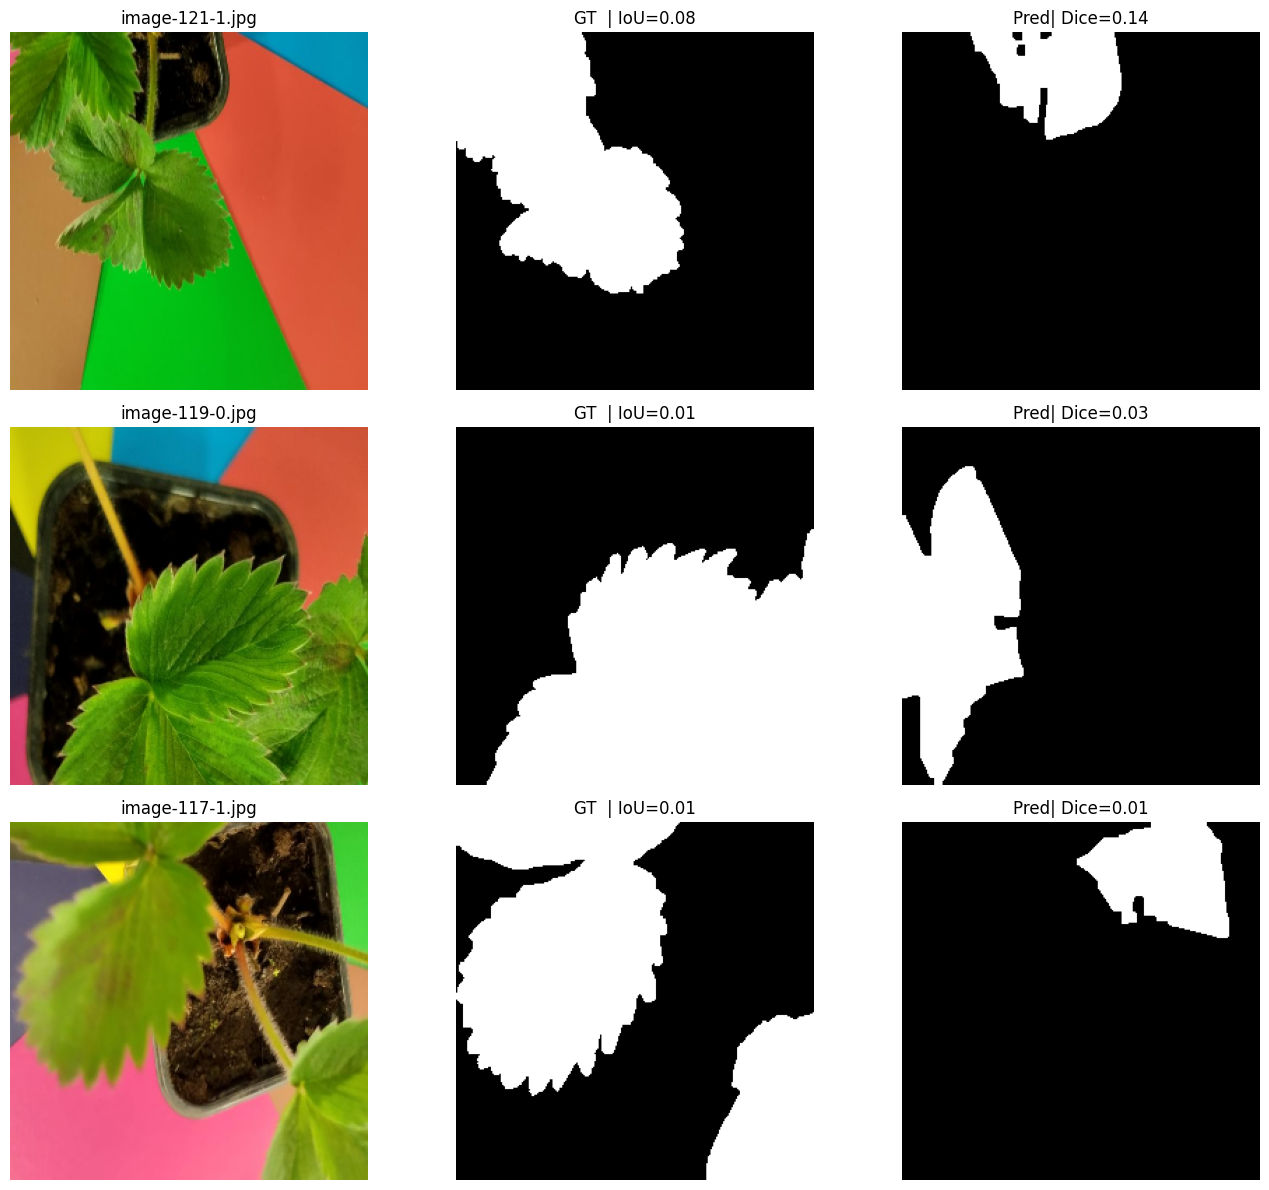


Why do failures happen?
- Low contrast between leaf and background.
- Uneven lighting causing Otsu to pick a bad threshold.
- Background texture similar to the leaf.
- Multiple leaf regions — only largest is kept, others are missed.


In [29]:
# Task 4: Sort by IoU to find best and worst cases

all_results = []

for img_path, mask_path in pairs[:50]:
    img_i = read_image(img_path)
    gt_i  = read_mask(mask_path)
    _, _, pred_i = segment_simple(img_i)
    m = segmentation_metrics(gt_i, pred_i)
    all_results.append({
        "img_path":  img_path,
        "mask_path": mask_path,
        **m
    })

all_results.sort(key=lambda x: x["iou"], reverse=True)

# Top 3 successes
successes = all_results[:3]
# Bottom 3 failures
failures  = all_results[-3:]

print("=== 3 SUCCESS CASES (highest IoU) ===")
success_imgs, success_titles = [], []
for r in successes:
    img_i = read_image(r["img_path"])
    gt_i  = read_mask(r["mask_path"])
    _, _, pred_i = segment_simple(img_i)
    success_imgs  += [img_i, gt_i, pred_i]
    success_titles += [
        r["img_path"].name[:20],
        f"GT  | IoU={r['iou']:.2f}",
        f"Pred| Dice={r['dice']:.2f}"
    ]
show_many(success_imgs, success_titles, cols=3, size=(14, 12))

print("=== 3 FAILURE CASES (lowest IoU) ===")
failure_imgs, failure_titles = [], []
for r in failures:
    img_i = read_image(r["img_path"])
    gt_i  = read_mask(r["mask_path"])
    _, _, pred_i = segment_simple(img_i)
    failure_imgs  += [img_i, gt_i, pred_i]
    failure_titles += [
        r["img_path"].name[:20],
        f"GT  | IoU={r['iou']:.2f}",
        f"Pred| Dice={r['dice']:.2f}"
    ]
show_many(failure_imgs, failure_titles, cols=3, size=(14, 12))

print("\nWhy do failures happen?")
print("- Low contrast between leaf and background.")
print("- Uneven lighting causing Otsu to pick a bad threshold.")
print("- Background texture similar to the leaf.")
print("- Multiple leaf regions — only largest is kept, others are missed.")

---
# Task 5 — Adaptive Thresholding vs Otsu

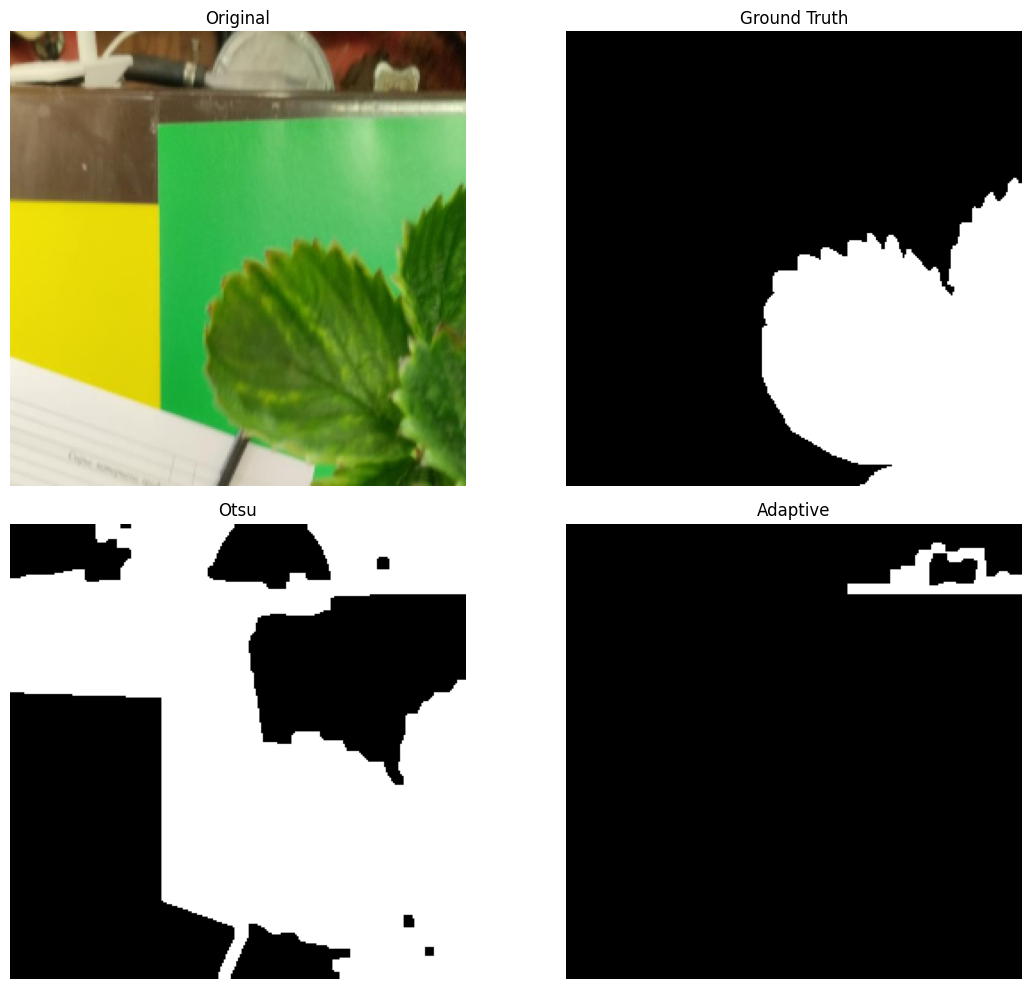

Metric             Otsu   Adaptive
----------------------------------
accuracy         0.6883     0.7031
precision        0.4700     0.0000
recall           0.9504     0.0000
f1_score         0.6290     0.0000
iou              0.4588     0.0000
dice             0.6290     0.0000

Task 5 Conclusion:
Otsu: Uses ONE global threshold → works well when contrast is uniform.
Adaptive: Computes different threshold per local region.
  Better when lighting is uneven across the image.
  Can produce noisier results on uniform images.
For leaf segmentation with clean background: Otsu is usually better.
For uneven lighting or field photos: Adaptive is more robust.


In [30]:
# Task 5: Adaptive thresholding vs Otsu — compare on one image

img_t5 = read_image(pairs[2][0])
gt_t5  = read_mask(pairs[2][1])

# --- Otsu pipeline ---
gray_t5 = cv2.cvtColor(img_t5, cv2.COLOR_RGB2GRAY)
blur_t5 = cv2.GaussianBlur(gray_t5, (5, 5), 0)
_, otsu_mask = cv2.threshold(blur_t5, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((5, 5), np.uint8)
otsu_mask = cv2.morphologyEx(otsu_mask, cv2.MORPH_OPEN, kernel)
otsu_mask = cv2.morphologyEx(otsu_mask, cv2.MORPH_CLOSE, kernel)
otsu_mask = largest_component(otsu_mask)

# --- Adaptive pipeline ---
adaptive_raw = cv2.adaptiveThreshold(
    blur_t5, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 21, 4
)
adaptive_mask = cv2.morphologyEx(adaptive_raw, cv2.MORPH_OPEN, kernel)
adaptive_mask = cv2.morphologyEx(adaptive_mask, cv2.MORPH_CLOSE, kernel)
adaptive_mask = largest_component(adaptive_mask)

show_many(
    [img_t5, gt_t5, otsu_mask, adaptive_mask],
    ["Original", "Ground Truth", "Otsu", "Adaptive"],
    cols=2, size=(12, 10)
)

m_otsu = segmentation_metrics(gt_t5, otsu_mask)
m_adap = segmentation_metrics(gt_t5, adaptive_mask)

print(f"{'Metric':<12} {'Otsu':>10} {'Adaptive':>10}")
print("-" * 34)
for k in m_otsu:
    print(f"{k:<12} {m_otsu[k]:>10.4f} {m_adap[k]:>10.4f}")

print()
print("Task 5 Conclusion:")
print("Otsu: Uses ONE global threshold → works well when contrast is uniform.")
print("Adaptive: Computes different threshold per local region.")
print("  Better when lighting is uneven across the image.")
print("  Can produce noisier results on uniform images.")
print("For leaf segmentation with clean background: Otsu is usually better.")
print("For uneven lighting or field photos: Adaptive is more robust.")

---
# Summary: Method Comparison Table

Final comparison (Mean IoU over 20 images):


,Method,Mean IoU
0,Otsu 5x5,0.5487
1,Otsu 3x3,0.5409
2,Adaptive,0.0203


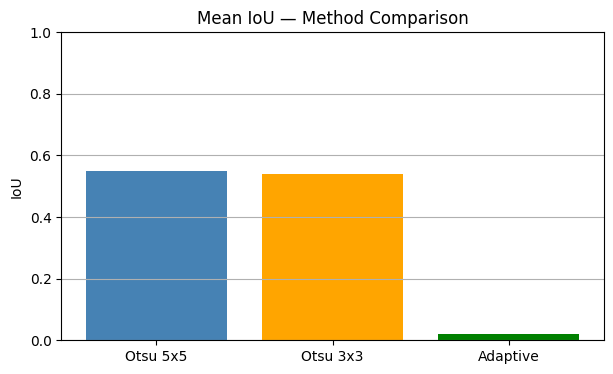

In [31]:
# Evaluate all 3 variants on 20 images for a final comparison table

compare_results = {"otsu_5x5": [], "otsu_3x3": [], "adaptive": []}

for img_path, mask_path in pairs[:20]:
    img_i = read_image(img_path)
    gt_i  = read_mask(mask_path)

    # Otsu 5x5
    _, _, p1 = segment_simple(img_i, kernel_size=(5,5))
    compare_results["otsu_5x5"].append(segmentation_metrics(gt_i, p1)["iou"])

    # Otsu 3x3
    _, _, p2 = segment_simple(img_i, kernel_size=(3,3))
    compare_results["otsu_3x3"].append(segmentation_metrics(gt_i, p2)["iou"])

    # Adaptive
    g = cv2.cvtColor(img_i, cv2.COLOR_RGB2GRAY)
    bl = cv2.GaussianBlur(g, (5,5), 0)
    am = cv2.adaptiveThreshold(bl, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY_INV, 21, 4)
    k = np.ones((5,5), np.uint8)
    am = cv2.morphologyEx(am, cv2.MORPH_OPEN, k)
    am = cv2.morphologyEx(am, cv2.MORPH_CLOSE, k)
    am = largest_component(am)
    compare_results["adaptive"].append(segmentation_metrics(gt_i, am)["iou"])

summary_df = pd.DataFrame({
    "Method":   ["Otsu 5x5", "Otsu 3x3", "Adaptive"],
    "Mean IoU": [
        np.mean(compare_results["otsu_5x5"]),
        np.mean(compare_results["otsu_3x3"]),
        np.mean(compare_results["adaptive"]),
    ]
})

print("Final comparison (Mean IoU over 20 images):")
display(summary_df.round(4))

plt.figure(figsize=(7, 4))
plt.bar(summary_df["Method"], summary_df["Mean IoU"],
        color=["steelblue", "orange", "green"])
plt.title("Mean IoU — Method Comparison")
plt.ylabel("IoU")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()